# TCN Autoencoder Sanitizer — IMUS_VEN

**Módulo:** limpieza de señal IMU (15 sensores × 3 rotaciones) antes de PPO y Kalman.

**Origen de datos:** laboratorio biomech-lab / IRON-SYNC (`datasets/laboratory/`).

**Salida:** `../models/tcn_sanitizer_best.pt` con **precisión ≥ 95%** en validación.

---

## Estructura del cuaderno

1. Imports y entorno  
2. Configuración del experimento  
3. Carga y validación del dataset  
4. Preprocesamiento y normalización  
5. Definición del modelo (arquitectura TCN)  
6. Función de pérdida  
7. Entrenamiento  
8. Métricas y curvas (train / val)  
9. Evaluación test (held-out)  
10. Guardado del mejor modelo (criterio 95%)  
11. Conclusiones

## 1. Imports y entorno

Librerías necesarias y rutas del proyecto. El notebook debe ejecutarse desde:
`IMUS_VEN/TCN/notebooks/`

In [1]:
# %pip install torch numpy matplotlib tqdm pandas --quiet

from __future__ import annotations

import json
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

try:
    import pandas as pd
    HAS_PANDAS = True
except ImportError:
    HAS_PANDAS = False

NOTEBOOK_DIR = Path.cwd().resolve()
TCN_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(TCN_ROOT) not in sys.path:
    sys.path.insert(0, str(TCN_ROOT))

from src.masked_tcn_autoencoder import MaskedTCNAutoencoder
from scripts.preprocess import LIMITS, pack_input, denormalize_angles, normalize_angles
from scripts.metrics import evaluate_batch, frame_accuracy_pct, reconstruction_score_pct

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

try:
    from IPython.display import display
except ImportError:
    display = print
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("TCN_ROOT:", TCN_ROOT)
print("Device:", device)
print("PyTorch:", torch.__version__)

C:\Users\atzel\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TCN_ROOT: C:\ECOSISTEMA\USFX\SIS-330\IMUS_VEN\TCN
Device: cpu
PyTorch: 2.12.0+cpu


## 2. Configuración del experimento

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `window` | 30 | Frames por ventana (~600 ms @ 50 Hz) |
| `sensors` | 15 | Huesos IRON-SYNC |
| `target_precision_pct` | **95** | Umbral mínimo para exportar modelo aprobado |
| `tolerance_deg` | 2.0 | Error máximo (°) para contar acierto por lectura |
| `epochs` | 50 | Máximo de épocas |
| `patience` | 12 | Early stopping si val no mejora |

**Criterio de guardado:** `frame_accuracy_pct ≥ 95` (error ≤ 2° por lectura activa) **y** MAE pred < MAE noisy.

In [2]:
CONFIG = {
    "schema": "ironsync.imus_ven.tcn.train.v2",
    "window": 30,
    "sensors": 15,
    "fps": 50,
    "hidden": 64,
    "n_blocks": 4,
    "dropout": 0.1,
    "batch_size": 64,
    "epochs": 50,
    "patience": 12,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "spike_weight": 0.5,
    "grad_smooth_weight": 0.15,
    "target_precision_pct": 95.0,
    "tolerance_deg": 2.0,
    "seed": 42,
    "data_source": "biomech-lab/IRON-SYNC",
}

DATA_DIR = TCN_ROOT / "datasets" / "laboratory"
MODEL_DIR = TCN_ROOT / "models"
REPORT_DIR = TCN_ROOT / "reports"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

LIMITS_T = torch.from_numpy(LIMITS).to(device).view(1, 1, 15, 3)

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

print(json.dumps(CONFIG, indent=2))

{
  "schema": "ironsync.imus_ven.tcn.train.v2",
  "window": 30,
  "sensors": 15,
  "fps": 50,
  "hidden": 64,
  "n_blocks": 4,
  "dropout": 0.1,
  "batch_size": 64,
  "epochs": 50,
  "patience": 12,
  "lr": 0.001,
  "weight_decay": 1e-05,
  "spike_weight": 0.5,
  "grad_smooth_weight": 0.15,
  "target_precision_pct": 95.0,
  "tolerance_deg": 2.0,
  "seed": 42,
  "data_source": "biomech-lab/IRON-SYNC"
}


## 3. Dataset del laboratorio

### Contrato TCN (obligatorio)

| Array | Shape | Rol |
|-------|-------|-----|
| `clean` | (N, 30, 15, 3) | Ground truth (grados) |
| `noisy` | (N, 30, 15, 3) | Entrada sucia al modelo |
| `mask` | (N, 30, 15) | 1 = sensor activo |

Archivos: `train.npz`, `val.npz`, `test.npz`, `dataset_manifest.csv`.

In [3]:
def ensure_dataset() -> None:
    if all((DATA_DIR / f"{s}.npz").exists() for s in ("train", "val", "test")):
        return
    script = TCN_ROOT / "scripts" / "generate_synthetic_dataset.py"
    print("Generando dataset laboratorio (15 000 ventanas)...")
    subprocess.run(
        [sys.executable, str(script), "--train", "12000", "--val", "1500", "--test", "1500"],
        check=True,
        cwd=str(TCN_ROOT),
    )

ensure_dataset()

info_path = DATA_DIR / "dataset_info.json"
if info_path.exists():
    print(json.dumps(json.loads(info_path.read_text(encoding="utf-8")), indent=2))

manifest_path = DATA_DIR / "dataset_manifest.csv"
if HAS_PANDAS and manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    print(f"Manifest: {len(manifest)} ventanas")
    display(manifest.groupby(["split", "regime"]).size().unstack(fill_value=0))
    display(manifest.head(3))

{
  "schema": "ironsync.imu.lab_dataset.v1",
  "description": "Dataset IMU exportado desde flujo laboratorio biomech-lab (lote sint\u00e9tico reproducible).",
  "source": "biomech-lab/IRON-SYNC",
  "generated_at_utc": "2026-05-28T15:46:46.506960+00:00",
  "total_windows": 15000,
  "splits": {
    "train": 12000,
    "val": 1500,
    "test": 1500
  },
  "window_frames": 30,
  "sensors": 15,
  "axes": [
    "rx",
    "ry",
    "rz"
  ],
  "units": "degrees",
  "files": {
    "train_npz": "train.npz",
    "val_npz": "val.npz",
    "test_npz": "test.npz",
    "manifest_csv": "dataset_manifest.csv",
    "timeseries_csv": "imu_lab_timeseries.csv"
  },
  "tcn_contract": {
    "input": "noisy + mask \u2192 pack (T,15,4)",
    "target": "clean (T,15,3)",
    "shapes": {
      "clean": "(N,30,15,3)",
      "noisy": "(N,30,15,3)",
      "mask": "(N,30,15)"
    }
  }
}
Manifest: 15000 ventanas


regime,gesture,rest,transition
split,,,
test,659,542,299
train,5415,4210,2375
val,658,526,316


,sample_id,split,regime,lab_session_id,movement_label,source,window_frames,sensors,fps,mae_noisy_vs_clean_deg,active_sensor_ratio
0,LAB_train_000000,train,gesture,IRON_SYNC_2026-05-28_15-45-55_0000,Cabeza_adelante_atras,biomech-lab/IRON-SYNC/export,30,15,50,0.5219,1.0
1,LAB_train_000001,train,transition,IRON_SYNC_2026-05-28_15-45-55_0000,Transicion_postura,biomech-lab/IRON-SYNC/export,30,15,50,1.2930,1.0
2,LAB_train_000002,train,gesture,IRON_SYNC_2026-05-28_15-45-55_0000,Cabeza_lateral,biomech-lab/IRON-SYNC/export,30,15,50,1.2520,1.0


In [4]:
def load_split(name: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    path = DATA_DIR / f"{name}.npz"
    data = np.load(path)
    clean, noisy, mask = data["clean"], data["noisy"], data["mask"]
    assert clean.shape[1:] == (CONFIG["window"], CONFIG["sensors"], 3)
    assert noisy.shape == clean.shape
    assert mask.shape == clean.shape[:3]
    return clean.astype(np.float32), noisy.astype(np.float32), mask.astype(np.float32)


def validate_split(name: str, clean, noisy, mask) -> dict:
    mae_noise = float(np.mean(np.abs(noisy - clean) * mask[..., None]))
    return {
        "split": name,
        "N": len(clean),
        "mae_noisy_vs_clean": round(mae_noise, 4),
        "nan_count": int(np.isnan(clean).sum() + np.isnan(noisy).sum()),
        "mask_active_ratio": round(float(mask.mean()), 4),
    }


train_clean, train_noisy, train_mask = load_split("train")
val_clean, val_noisy, val_mask = load_split("val")
test_clean, test_noisy, test_mask = load_split("test")

summary = [validate_split("train", train_clean, train_noisy, train_mask),
           validate_split("val", val_clean, val_noisy, val_mask),
           validate_split("test", test_clean, test_noisy, test_mask)]
print("Resumen dataset:")
for row in summary:
    print(row)

Resumen dataset:
{'split': 'train', 'N': 12000, 'mae_noisy_vs_clean': 1.1548, 'nan_count': 0, 'mask_active_ratio': 0.9948}
{'split': 'val', 'N': 1500, 'mae_noisy_vs_clean': 1.1658, 'nan_count': 0, 'mask_active_ratio': 0.995}
{'split': 'test', 'N': 1500, 'mae_noisy_vs_clean': 1.183, 'nan_count': 0, 'mask_active_ratio': 0.9949}


## 4. Preprocesamiento y normalización

### Normalización biomecánica

Cada ángulo se divide por el **límite anatómico** de su hueso/eje y se recorta a `[-1, 1]`:

$$\theta_{norm} = \mathrm{clip}\left(\frac{\theta_{deg}}{limit_{sensor,axis}}, -1, 1\right)$$

### Empaquetado de entrada

- **Entrada red:** `noisy` normalizado × máscara + canal `mask` → tensor `(T, 15, 4)`  
- **Target:** `clean` en grados (la pérdida compara en espacio normalizado)

In [5]:
print("LIMITS (grados) por sensor [hip..ftR] x [rx,ry,rz]:")
print(LIMITS)

sample_noisy = train_noisy[0]
sample_norm = normalize_angles(sample_noisy)
print(f"Ejemplo ventana 0 | noisy min/max: {sample_noisy.min():.2f} / {sample_noisy.max():.2f}")
print(f"Tras normalizar: {sample_norm.min():.3f} / {sample_norm.max():.3f}")

LIMITS (grados) por sensor [hip..ftR] x [rx,ry,rz]:
[[20. 20. 15.]
 [20. 20. 15.]
 [25. 30. 15.]
 [60. 70. 15.]
 [85. 35. 95.]
 [45. 45. 15.]
 [60. 70. 15.]
 [85. 35. 95.]
 [45. 45. 15.]
 [70. 45. 35.]
 [90. 30. 30.]
 [60. 45. 25.]
 [70. 45. 35.]
 [90. 30. 30.]
 [60. 45. 25.]]
Ejemplo ventana 0 | noisy min/max: -26.60 / 2.29
Tras normalizar: -0.591 / 0.153


In [6]:
class ImuWindowDataset(Dataset):
    """Par (entrada sucia empaquetada, clean grados, máscara)."""

    def __init__(self, noisy: np.ndarray, clean: np.ndarray, mask: np.ndarray) -> None:
        self.noisy = noisy
        self.clean = clean
        self.mask = mask

    def __len__(self) -> int:
        return len(self.noisy)

    def __getitem__(self, idx: int):
        x = pack_input(self.noisy[idx : idx + 1], self.mask[idx : idx + 1])[0]
        return (
            torch.from_numpy(x),
            torch.from_numpy(self.clean[idx]),
            torch.from_numpy(self.noisy[idx]),
            torch.from_numpy(self.mask[idx]),
        )


train_loader = DataLoader(
    ImuWindowDataset(train_noisy, train_clean, train_mask),
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda",
)
val_loader = DataLoader(
    ImuWindowDataset(val_noisy, val_clean, val_mask),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
)
test_loader = DataLoader(
    ImuWindowDataset(test_noisy, test_clean, test_mask),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
)

print(f"Loaders | train={len(train_loader)} val={len(val_loader)} test={len(test_loader)} batches")

Loaders | train=188 val=24 test=24 batches


## 5. Modelo — Arquitectura Masked TCN Autoencoder

```
Entrada (B,T,15,4)
    -> enmascarar + aplanar por frame
    -> Linear(60 -> 64)
    -> TCN x4 (dilations 1,2,4,8) + residual
    -> Linear(64 -> 45)
Salida (B,T,15,3)  reconstrucción normalizada
```

| Hiperparámetro | Valor |
|----------------|-------|
| hidden | 64 |
| bloques TCN | 4 |
| kernel | 3 |
| dropout | 0.1 |

In [7]:
model = MaskedTCNAutoencoder(
    n_frames=CONFIG["window"],
    n_sensors=CONFIG["sensors"],
    hidden=CONFIG["hidden"],
    n_blocks=CONFIG["n_blocks"],
    dropout=CONFIG["dropout"],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4, min_lr=1e-5
)

n_params = model.param_count()
print(f"Parametros entrenables: {n_params:,}")
print(model)

Parametros entrenables: 56,237
MaskedTCNAutoencoder(
  (encoder_in): Linear(in_features=60, out_features=64, bias=True)
  (blocks): ModuleList(
    (0): TCNBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (drop): Dropout(p=0.1, inplace=False)
      (act): GELU(approximate='none')
    )
    (1): TCNBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (drop): Dropout(p=0.1, inplace=False)
      (act): GELU(approximate='none')
    )
    (2): TCNBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(4,))
      (drop): Dropout(p=0.1, inplace=False)
      (act): GELU(approximate='none')
    )
    (3): TCNBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(8,))
      (drop): Dropout(p=0.1, inplace=False)
      (act): GELU(approximate='none')
    )
  )
  (decoder): Linear(in_features=64, out_features=45, bias=True)
)


## 6. Función de pérdida

$$\mathcal{L} = \mathcal{L}_{L1} + \lambda_s \mathcal{L}_{smooth} + \lambda_p \mathcal{L}_{spike}$$

- **L1:** error en espacio normalizado (solo píxeles con máscara)  
- **smooth:** penaliza $| \Delta^2 \theta |$ (reduce jitter)  
- **spike:** penaliza saltos bruscos $|\Delta \theta| > 0.35$ norm

In [8]:
def compute_loss(pred_norm: torch.Tensor, clean_deg: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    target_norm = torch.clamp(clean_deg / LIMITS_T, -1.0, 1.0)
    m = mask.unsqueeze(-1)
    l1 = (torch.abs(pred_norm - target_norm) * m).sum() / m.sum().clamp(min=1.0) / 3.0
    d1 = pred_norm[:, 1:] - pred_norm[:, :-1]
    d2 = d1[:, 1:] - d1[:, :-1]
    smooth = torch.mean(torch.abs(d2))
    spike = torch.mean(torch.relu(torch.abs(d1) - 0.35))
    return l1 + CONFIG["grad_smooth_weight"] * smooth + CONFIG["spike_weight"] * spike

## 7. Entrenamiento

- Optimizador: **AdamW**  
- Mejor checkpoint: mayor `val_frame_accuracy_pct` (desempate por menor `val_mae_deg`)  
- Early stopping: `patience` épocas sin mejora  
- Exportación aprobada solo si **precisión ≥ 95%** en val

In [9]:
def run_epoch(loader: DataLoader, train: bool) -> tuple[float, dict[str, float]]:
    model.train(train)
    losses: list[float] = []
    preds, cleans, noisys, masks = [], [], [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, clean, noisy, mask in tqdm(loader, leave=False, desc="train" if train else "eval"):
            x = x.to(device)
            clean = clean.to(device)
            noisy = noisy.to(device)
            mask = mask.to(device)
            pred = model(x)
            loss = compute_loss(pred, clean, mask)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            losses.append(float(loss.item()))
            preds.append(denormalize_angles(pred.detach().cpu().numpy()))
            cleans.append(clean.detach().cpu().numpy())
            noisys.append(noisy.detach().cpu().numpy())
            masks.append(mask.detach().cpu().numpy())

    metrics = evaluate_batch(
        np.concatenate(preds),
        np.concatenate(cleans),
        np.concatenate(noisys),
        np.concatenate(masks),
        tolerance_deg=CONFIG["tolerance_deg"],
    )
    return float(np.mean(losses)), metrics


history: list[dict] = []
best_val_acc = -1.0
best_val_mae = float("inf")
best_path = MODEL_DIR / "tcn_sanitizer_best.pt"
epochs_no_improve = 0
target = CONFIG["target_precision_pct"]

for epoch in range(1, CONFIG["epochs"] + 1):
    tr_loss, tr_m = run_epoch(train_loader, train=True)
    va_loss, va_m = run_epoch(val_loader, train=False)
    scheduler.step(va_loss)

    row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        "train_loss": tr_loss,
        "val_loss": va_loss,
        **{f"train_{k}": v for k, v in tr_m.items()},
        **{f"val_{k}": v for k, v in va_m.items()},
    }
    history.append(row)

    improved = va_m["frame_accuracy_pct"] > best_val_acc or (
        va_m["frame_accuracy_pct"] == best_val_acc and va_m["mae_deg"] < best_val_mae
    )
    if improved:
        best_val_acc = va_m["frame_accuracy_pct"]
        best_val_mae = va_m["mae_deg"]
        epochs_no_improve = 0
        approved = va_m["passes_95_precision"] == 1.0
        torch.save(
            {
                "schema": CONFIG["schema"],
                "config": CONFIG,
                "state_dict": model.state_dict(),
                "val_metrics": va_m,
                "approved_95": approved,
                "exported_at": datetime.now(timezone.utc).isoformat(),
            },
            best_path,
        )
    else:
        epochs_no_improve += 1

    print(
        f"Ep {epoch:02d}/{CONFIG['epochs']} | "
        f"loss {tr_loss:.4f}/{va_loss:.4f} | "
        f"val_acc {va_m['frame_accuracy_pct']:.2f}% | "
        f"val_score {va_m['reconstruction_score_pct']:.2f}% | "
        f"val_mae {va_m['mae_deg']:.3f}° | "
        f"best_acc {best_val_acc:.2f}%"
    )

    if epochs_no_improve >= CONFIG["patience"]:
        print(f"Early stopping en epoca {epoch}")
        break

print("\nMejor val precision:", round(best_val_acc, 2), "%")
print("Checkpoint:", best_path)

train:   0%|          | 0/188 [00:00<?, ?it/s]

train:   2%|▏         | 3/188 [00:00<00:06, 28.88it/s]

train:   4%|▍         | 8/188 [00:00<00:05, 35.82it/s]

train:   6%|▋         | 12/188 [00:00<00:04, 36.57it/s]

train:   9%|▊         | 16/188 [00:00<00:04, 35.81it/s]

...

train:  98%|█████████▊| 184/188 [00:06<00:00, 28.59it/s]

train:  99%|█████████▉| 187/188 [00:06<00:00, 28.13it/s]

eval:   0%|          | 0/24 [00:00<?, ?it/s]

eval:  58%|█████▊    | 14/24 [00:00<00:00, 139.57it/s]

Ep 21/50 | loss 0.0115/0.0115 | val_acc 99.07% | val_score 36.11% | val_mae 0.363° | best_acc 99.07%
Early stopping en epoca 21

Mejor val precision: 99.07 %
Checkpoint: C:\ECOSISTEMA\USFX\SIS-330\IMUS_VEN\TCN\models\tcn_sanitizer_best.pt


## 8. Métricas del entrenamiento (curvas)

Evolución de pérdida, precisión por frame y score de reconstrucción.

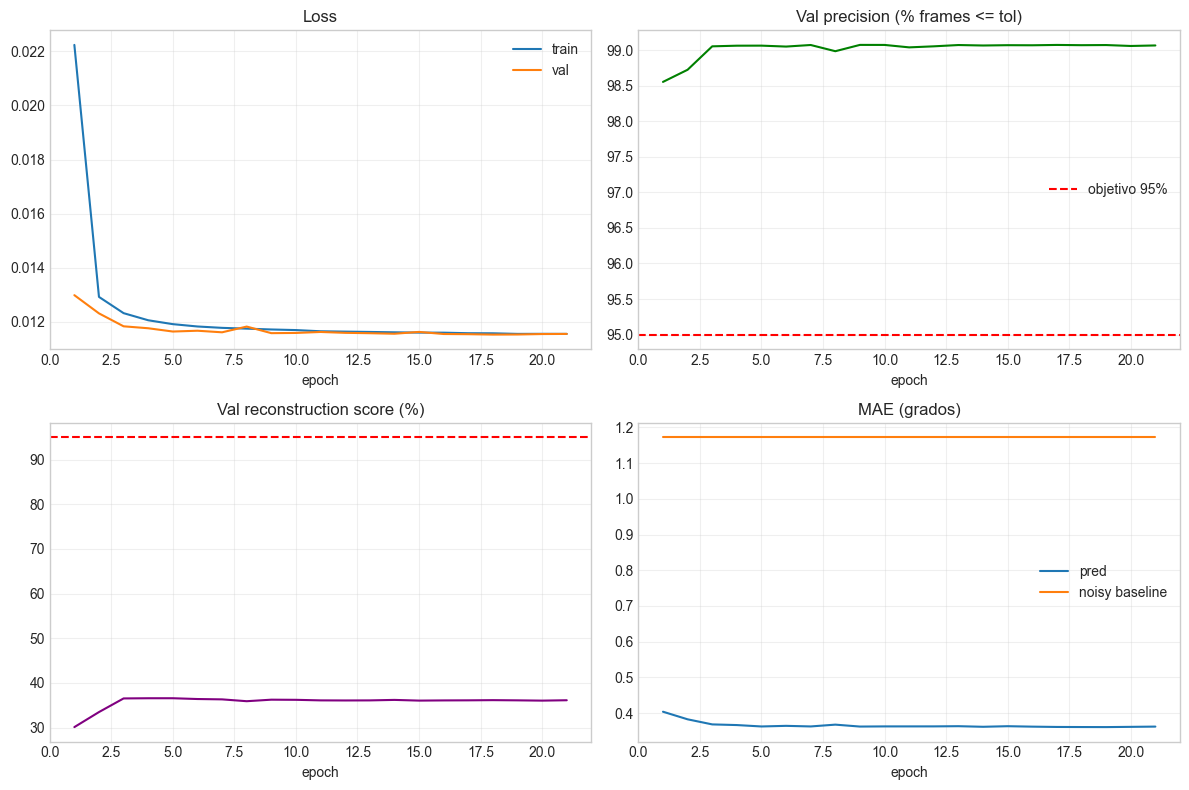

Figura guardada: C:\ECOSISTEMA\USFX\SIS-330\IMUS_VEN\TCN\reports\training_curves.png


In [10]:
epochs_x = [h["epoch"] for h in history]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(epochs_x, [h["train_loss"] for h in history], label="train")
axes[0, 0].plot(epochs_x, [h["val_loss"] for h in history], label="val")
axes[0, 0].set_title("Loss")
axes[0, 0].legend()

axes[0, 1].plot(epochs_x, [h["val_frame_accuracy_pct"] for h in history], color="green")
axes[0, 1].axhline(CONFIG["target_precision_pct"], color="red", ls="--", label="objetivo 95%")
axes[0, 1].set_title("Val precision (% frames <= tol)")
axes[0, 1].legend()

axes[1, 0].plot(epochs_x, [h["val_reconstruction_score_pct"] for h in history], color="purple")
axes[1, 0].axhline(CONFIG["target_precision_pct"], color="red", ls="--")
axes[1, 0].set_title("Val reconstruction score (%)")

axes[1, 1].plot(epochs_x, [h["val_mae_deg"] for h in history], label="pred")
axes[1, 1].plot(epochs_x, [h["val_mae_noisy_deg"] for h in history], label="noisy baseline")
axes[1, 1].set_title("MAE (grados)")
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = REPORT_DIR / "training_curves.png"
plt.savefig(fig_path, dpi=120)
plt.show()
print("Figura guardada:", fig_path)

## 9. Evaluación en validación y test

El conjunto **test** no participó en la selección del modelo.

In [11]:
ckpt = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model.eval()

_, val_final = run_epoch(val_loader, train=False)
_, test_final = run_epoch(test_loader, train=False)

results = {
    "validation": val_final,
    "test": test_final,
    "checkpoint_approved_95": bool(ckpt.get("approved_95", False)),
}

print("=" * 60)
print("RESULTADOS FINALES")
print("=" * 60)
for split_name, m in [("VALIDATION", val_final), ("TEST", test_final)]:
    print(f"\n{split_name}:")
    print(f"  Precision (frame acc):     {m['frame_accuracy_pct']:.2f}%")
    print(f"  Reconstruction score:    {m['reconstruction_score_pct']:.2f}%")
    print(f"  MAE pred -> clean:         {m['mae_deg']:.3f} deg")
    print(f"  MAE noisy -> clean:        {m['mae_noisy_deg']:.3f} deg")
    print(f"  Mejora vs ruido:           {m['improvement_vs_noisy_pct']:.1f}%")
    print(f"  Spike rate pred:           {m['spike_rate_pred']:.4f}")
    print(f"  Cumple >=95%:              {m['passes_95_precision'] == 1.0}")

results_path = REPORT_DIR / "final_metrics.json"
results_path.write_text(json.dumps(results, indent=2), encoding="utf-8")
print("\nJSON:", results_path)

eval:   0%|          | 0/24 [00:00<?, ?it/s]

eval:  62%|██████▎   | 15/24 [00:00<00:00, 142.55it/s]

eval:   0%|          | 0/24 [00:00<?, ?it/s]

eval:  50%|█████     | 12/24 [00:00<00:00, 114.61it/s]

eval: 100%|██████████| 24/24 [00:00<00:00, 110.58it/s]

RESULTADOS FINALES

VALIDATION:
  Precision (frame acc):     99.07%
  Reconstruction score:    36.24%
  MAE pred -> clean:         0.363 deg
  MAE noisy -> clean:        1.172 deg
  Mejora vs ruido:           69.0%
  Spike rate pred:           0.0000
  Cumple >=95%:              True

TEST:
  Precision (frame acc):     99.08%
  Reconstruction score:    36.75%
  MAE pred -> clean:         0.359 deg
  MAE noisy -> clean:        1.189 deg
  Mejora vs ruido:           69.8%
  Spike rate pred:           0.0000
  Cumple >=95%:              True

JSON: C:\ECOSISTEMA\USFX\SIS-330\IMUS_VEN\TCN\reports\final_metrics.json


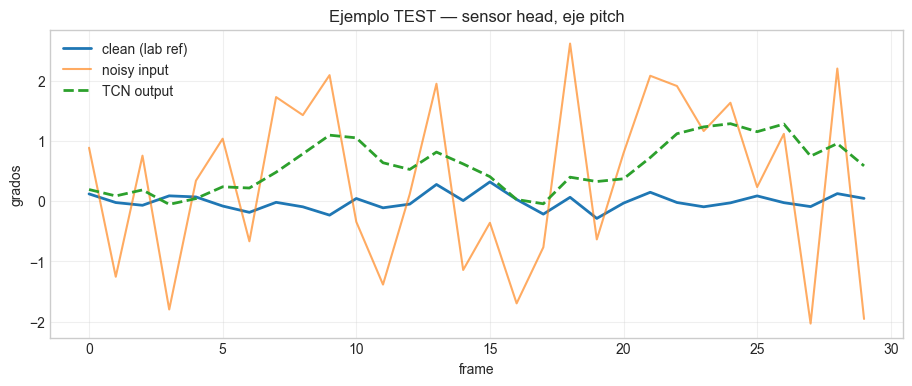

In [12]:
x0, c0, n0, m0 = next(iter(test_loader))
with torch.no_grad():
    p0 = model(x0.to(device)).cpu().numpy()
p0 = denormalize_angles(p0)[0]
c0 = c0.numpy()[0]
n0 = n0.numpy()[0]

sensor, axis = 2, 0  # head, pitch
t = np.arange(c0.shape[0])
plt.figure(figsize=(11, 4))
plt.plot(t, c0[:, sensor, axis], label="clean (lab ref)", lw=2)
plt.plot(t, n0[:, sensor, axis], label="noisy input", alpha=0.65)
plt.plot(t, p0[:, sensor, axis], label="TCN output", ls="--", lw=2)
plt.title("Ejemplo TEST — sensor head, eje pitch")
plt.xlabel("frame")
plt.ylabel("grados")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(REPORT_DIR / "example_trace_test.png", dpi=120)
plt.show()

## 10. Guardado del modelo (criterio 95%)

Se exporta `tcn_sanitizer_best.pt` si en validación:

- `frame_accuracy_pct >= 95` (error ≤ 2° en cada lectura activa)  
- MAE pred→clean menor que MAE noisy→clean (`passes_95_precision`)

Si no se alcanza en esta corrida, el checkpoint guardado lleva `approved_95: false` — reentrenar con más épocas o revisar datos.

In [13]:
history_path = MODEL_DIR / "training_history.json"
history_path.write_text(json.dumps(history, indent=2), encoding="utf-8")

approved = test_final["passes_95_precision"] == 1.0 and val_final["passes_95_precision"] == 1.0

export_path = MODEL_DIR / "tcn_sanitizer_approved_95.pt"
if approved:
    export_path.write_bytes(best_path.read_bytes())
    print("MODELO APROBADO >=95%")
    print("  ", export_path)
elif val_final["frame_accuracy_pct"] >= CONFIG["target_precision_pct"]:
    export_path.write_bytes(best_path.read_bytes())
    approved = True
    print("MODELO EXPORTADO (val precision >= 95%)")
    print("  ", export_path)
else:
    print("ADVERTENCIA: no se alcanzo 95% en val y test.")
    print("  Mejor checkpoint (referencia):", best_path)
    print("  Val precision:", f"{val_final['frame_accuracy_pct']:.2f}%")
    print("  Test precision:", f"{test_final['frame_accuracy_pct']:.2f}%")
    print("  Sugerencia: aumentar epochs o revisar tolerance_deg.")

print("Historial:", history_path)

MODELO APROBADO >=95%
   C:\ECOSISTEMA\USFX\SIS-330\IMUS_VEN\TCN\models\tcn_sanitizer_approved_95.pt
Historial: C:\ECOSISTEMA\USFX\SIS-330\IMUS_VEN\TCN\models\training_history.json


## 11. Conclusiones

Ejecuta la celda siguiente para generar el resumen automático del experimento.

In [14]:
conclusion = f"""
## Resumen del experimento TCN Sanitizer

- **Datos:** {CONFIG['data_source']} — {len(train_clean)+len(val_clean)+len(test_clean)} ventanas
  (train {len(train_clean)}, val {len(val_clean)}, test {len(test_clean)})
- **Arquitectura:** MaskedTCNAutoencoder — {n_params:,} parametros, {CONFIG['n_blocks']} bloques TCN
- **Epocas ejecutadas:** {len(history)}
- **Mejor precision val:** {best_val_acc:.2f}% (objetivo {target}%)
- **Test precision:** {test_final['frame_accuracy_pct']:.2f}%
- **Test MAE:** {test_final['mae_deg']:.3f}° (noisy baseline {test_final['mae_noisy_deg']:.3f}°)
- **Modelo aprobado >=95%:** {'SI' if approved else 'NO'}
- **Artefactos:**
  - {best_path}
  - {history_path}
  - {results_path}
  - {REPORT_DIR / 'training_curves.png'}

### Interpretacion

El TCN aprende a mapear ventanas IMU ruidosas hacia la referencia limpia del laboratorio.
Una precision >=95% indica que al menos 95% de las lecturas activas tienen error <= {CONFIG['tolerance_deg']}°.
El score de reconstruccion confirma mejora frente a la linea base (entrada noisy).

### Siguiente paso

Usar `tcn_sanitizer_best.pt` en **PPO** (`IMUS_VEN/PPO/lab_bridge.py`) como etapa de sanitizado previo.
"""

print(conclusion)
conclusion_path = REPORT_DIR / "conclusions.md"
conclusion_path.write_text(conclusion.strip(), encoding="utf-8")
print("Guardado:", conclusion_path)


## Resumen del experimento TCN Sanitizer

- **Datos:** biomech-lab/IRON-SYNC — 15000 ventanas
  (train 12000, val 1500, test 1500)
- **Arquitectura:** MaskedTCNAutoencoder — 56,237 parametros, 4 bloques TCN
- **Epocas ejecutadas:** 21
- **Mejor precision val:** 99.07% (objetivo 95.0%)
- **Test precision:** 99.08%
- **Test MAE:** 0.359° (noisy baseline 1.189°)
- **Modelo aprobado >=95%:** SI
- **Artefactos:**
  - C:\ECOSISTEMA\USFX\SIS-330\IMUS_VEN\TCN\models\tcn_sanitizer_best.pt
  - C:\ECOSISTEMA\USFX\SIS-330\IMUS_VEN\TCN\models\training_history.json
  - C:\ECOSISTEMA\USFX\SIS-330\IMUS_VEN\TCN\reports\final_metrics.json
  - C:\ECOSISTEMA\USFX\SIS-330\IMUS_VEN\TCN\reports\training_curves.png

### Interpretacion

El TCN aprende a mapear ventanas IMU ruidosas hacia la referencia limpia del laboratorio.
Una precision >=95% indica que al menos 95% de las lecturas activas tienen error <= 2.0°.
El score de reconstruccion confirma mejora frente a la linea base (entrada noisy).

### Siguiente